In [1]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
path = Path("../results/")
df = pd.concat(map(pd.read_csv, path.rglob("*.csv")), ignore_index=True)

In [3]:
df.pivot_table(
    index=["BF", "mask", "speech_cov"], 
    values=["SDR_in", "SDR_out", "SIR_in", "SIR_out", "iSDR", "iSIR"]
).style.background_gradient(cmap='viridis', axis=0)

In [28]:
# apply some filters
df_filtered = df[
    df['speech_cov'] == 'mix'
]

df_filtered.pivot_table(
    index=["BF", "mask", "speech_cov"], 
    values=["SDR_in", "SDR_out", "SIR_in", "SIR_out", "iSDR", "iSIR"]
).style.background_gradient(cmap='viridis', axis=0)

In [30]:
df_results = df_filtered.copy()

In [31]:
bf_types = df_results["BF"].unique()
mask_types = df_results["mask"].unique()
speech_cov_types = df_results["speech_cov"].unique()


n_bf = len(bf_types)
n_masks = len(mask_types)

In [23]:
sns.set(style='whitegrid', context='paper', font_scale=1.2,
        rc={
            'figure.figsize':(3.5,3.15), 
            'lines.linewidth':2.,
            'font.family': 'sans-serif',
            'font.sans-serif': [u'Helvetica'],
            'text.usetex': False,
            })
pal = sns.cubehelix_palette(n_masks, start=0.5, rot=-0.5,dark=0.3, light=.75, reverse=True, hue=1.)
sns.set_palette(pal)

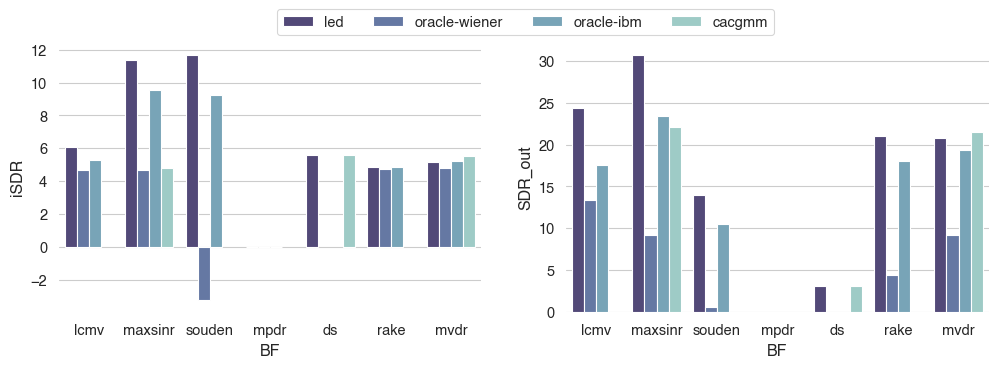

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.barplot(x="BF", y="iSDR", hue="mask", data=df_results, ax=ax[0])
sns.despine(offset=10, trim=False, left=True, bottom=True, ax=ax[0])

sns.barplot(x="BF", y="iSIR", hue="mask", data=df_results, ax=ax[1])
sns.despine(offset=10, trim=False, left=True, bottom=True, ax=ax[1])

# get lendgend handles and labels
handles, labels = ax[0].get_legend_handles_labels()
# place the legend on top of the figure
ax[0].legend(handles, labels, loc='upper left', bbox_to_anchor=(0.5, 1.15), ncol=4)
# turn off legend for the second plot
ax[1].get_legend().remove()
plt.ylabel("SDR_out")
plt.savefig("fa2025_mask_performances.pdf", dpi=300, bbox_inches='tight')